# 05 - Cross-Dataset Generalization Test

Tests whether an Autoencoder trained on CIC-IDS2017 generalizes to CIC-IoT2023, a structurally different dataset with its own feature extraction schema.

**Key challenge:** CIC-IDS2017 (78 features, bidirectional flow statistics) and CIC-IoT2023 (39 features, packet-header/protocol-flag statistics) share almost no directly matching columns. A reduced-feature model (12 common features: flag counts, packet length stats, IAT mean) is trained and tested to enable a genuine, if narrower, generalization comparison.

**Approach:** train a new, smaller Autoencoder on CIC-IDS2017 using only the 12 common features, evaluate it there as a fair baseline, then test the same model on the equivalent CIC-IoT2023 features without retraining or rescaling.

## Load CIC-IDS2017 and select the 12 common features

In [6]:
import pandas as pd

df = pd.read_csv('/home/vboxuser/FEAR/data/cicids2017_cleaned.csv')

common_features_ids2017 = [
    'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count',
    'ACK Flag Count', 'ECE Flag Count', 'Min Packet Length', 'Max Packet Length',
    'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'Flow IAT Mean'
]

X = df[common_features_ids2017]
y = df['Binary_Label']
print(X.shape)

(2520798, 12)


## Split and scale (benign-only training, same approach as the original Autoencoder)

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train_benign = X_train_full[y_train_full == 0]

scaler_reduced = StandardScaler()
X_train_scaled = scaler_reduced.fit_transform(X_train_benign)
X_test_scaled = scaler_reduced.transform(X_test)
print(X_train_scaled.shape, X_test_scaled.shape)

(1466539, 12) (756240, 12)


## Define and train the reduced Autoencoder (12 → 8 → 4 → 8 → 12)

In [8]:
import torch
import torch.nn as nn
import time

class ReducedAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8), nn.ReLU(),
            nn.Linear(8, 4), nn.ReLU()
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8), nn.ReLU(),
            nn.Linear(8, input_dim)
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model_reduced = ReducedAutoencoder(input_dim=X_train_scaled.shape[1])

X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_reduced.parameters(), lr=0.001)

from torch.utils.data import DataLoader, TensorDataset
train_loader = DataLoader(TensorDataset(X_train_tensor, X_train_tensor), batch_size=512, shuffle=True)

start = time.time()
epochs = 20
for epoch in range(epochs):
    total_loss = 0
    for batch, _ in train_loader:
        optimizer.zero_grad()
        output = model_reduced(batch)
        loss = criterion(output, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}')
print(f'Training took {time.time()-start:.1f} seconds')

Epoch 1/20, Loss: 0.3817
Epoch 2/20, Loss: 0.1795
Epoch 3/20, Loss: 0.1090
Epoch 4/20, Loss: 0.0848
Epoch 5/20, Loss: 0.0690
Epoch 6/20, Loss: 0.0561
Epoch 7/20, Loss: 0.0538
Epoch 8/20, Loss: 0.0525
Epoch 9/20, Loss: 0.0518
Epoch 10/20, Loss: 0.0508
Epoch 11/20, Loss: 0.0507
Epoch 12/20, Loss: 0.0505
Epoch 13/20, Loss: 0.0505
Epoch 14/20, Loss: 0.0505
Epoch 15/20, Loss: 0.0504
Epoch 16/20, Loss: 0.0503
Epoch 17/20, Loss: 0.0504
Epoch 18/20, Loss: 0.0503
Epoch 19/20, Loss: 0.0502
Epoch 20/20, Loss: 0.0502
Training took 136.2 seconds


## Results: Reduced-feature model on CIC-IDS2017 (baseline)

In [9]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

model_reduced.eval()
with torch.no_grad():
    reconstructions = model_reduced(X_test_tensor)
    recon_errors = torch.mean((X_test_tensor - reconstructions) ** 2, dim=1).numpy()

threshold_reduced = np.percentile(recon_errors[y_test.values == 0], 80)
preds_binary = (recon_errors > threshold_reduced).astype(int)

print(confusion_matrix(y_test, preds_binary))
print(classification_report(y_test, preds_binary))

[[502814 125704]
 [ 15757 111965]]
              precision    recall  f1-score   support

           0       0.97      0.80      0.88    628518
           1       0.47      0.88      0.61    127722

    accuracy                           0.81    756240
   macro avg       0.72      0.84      0.74    756240
weighted avg       0.89      0.81      0.83    756240



## Load and prepare CIC-IoT2023 with the equivalent 12 features

In [10]:
import glob

benign_files = glob.glob('/home/vboxuser/FEAR/data/CSV/Benign_Final/*.csv')[:2]
attack_files = glob.glob('/home/vboxuser/FEAR/data/CSV/DoS-SYN_Flood/*.csv')[:2]

df_benign = pd.concat([pd.read_csv(f) for f in benign_files], ignore_index=True)
df_attack = pd.concat([pd.read_csv(f) for f in attack_files], ignore_index=True)

df_benign['Binary_Label'] = 0
df_attack['Binary_Label'] = 1

df_iot = pd.concat([df_benign, df_attack], ignore_index=True)
print(df_iot.shape)
print(df_iot['Binary_Label'].value_counts())

(1120947, 40)
Binary_Label
0    605998
1    514949
Name: count, dtype: int64


## Align IoT2023 columns to the same feature order, clean, and scale

In [11]:
column_mapping = {
    'fin_flag_number': 'FIN Flag Count',
    'syn_flag_number': 'SYN Flag Count',
    'rst_flag_number': 'RST Flag Count',
    'psh_flag_number': 'PSH Flag Count',
    'ack_flag_number': 'ACK Flag Count',
    'ece_flag_number': 'ECE Flag Count',
    'Min': 'Min Packet Length',
    'Max': 'Max Packet Length',
    'AVG': 'Packet Length Mean',
    'Std': 'Packet Length Std',
    'Variance': 'Packet Length Variance',
    'IAT': 'Flow IAT Mean'
}

df_iot_renamed = df_iot.rename(columns=column_mapping)
X_iot = df_iot_renamed[common_features_ids2017]  # same order as training
y_iot = df_iot_renamed['Binary_Label']

# Clean, same as CIC-IDS2017 pipeline
import numpy as np
X_iot = X_iot.replace([np.inf, -np.inf], np.nan)
mask = ~X_iot.isna().any(axis=1)
X_iot = X_iot[mask]
y_iot = y_iot[mask]

print(X_iot.shape)

(1120905, 12)


## Test the CIC-IDS2017-trained model on CIC-IoT2023 (no refitting, no threshold recalculation)

In [12]:
X_iot_scaled = scaler_reduced.transform(X_iot)  # reuse the scaler fitted on CIC-IDS2017
X_iot_tensor = torch.FloatTensor(X_iot_scaled)

model_reduced.eval()
with torch.no_grad():
    reconstructions_iot = model_reduced(X_iot_tensor)
    recon_errors_iot = torch.mean((X_iot_tensor - reconstructions_iot) ** 2, dim=1).numpy()

preds_iot_binary = (recon_errors_iot > threshold_reduced).astype(int)  # same threshold as before

print(confusion_matrix(y_iot, preds_iot_binary))
print(classification_report(y_iot, preds_iot_binary))

[[  4346 601614]
 [     6 514939]]
              precision    recall  f1-score   support

           0       1.00      0.01      0.01    605960
           1       0.46      1.00      0.63    514945

    accuracy                           0.46   1120905
   macro avg       0.73      0.50      0.32   1120905
weighted avg       0.75      0.46      0.30   1120905



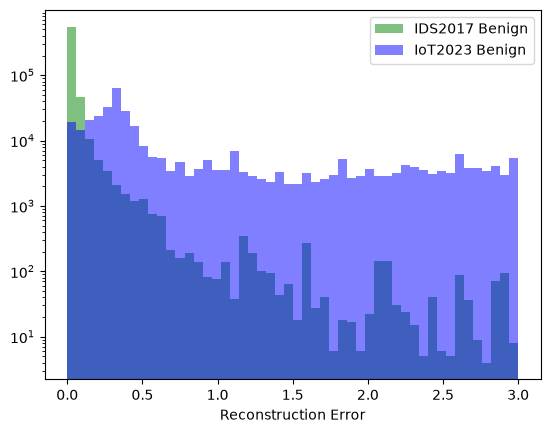

In [13]:
import matplotlib.pyplot as plt

plt.hist(recon_errors[y_test.values==0], bins=50, range=(0,3), alpha=0.5, label='IDS2017 Benign', color='green')
plt.hist(recon_errors_iot[y_iot.values==0], bins=50, range=(0,3), alpha=0.5, label='IoT2023 Benign', color='blue')
plt.legend()
plt.xlabel('Reconstruction Error')
plt.yscale('log')
plt.show()

In [14]:
threshold_iot_recalibrated = np.percentile(recon_errors_iot[y_iot.values == 0], 80)
print(f'Original threshold: {threshold_reduced:.4f}')
print(f'Recalibrated threshold: {threshold_iot_recalibrated:.4f}')

preds_iot_recalibrated = (recon_errors_iot > threshold_iot_recalibrated).astype(int)

print(confusion_matrix(y_iot, preds_iot_recalibrated))
print(classification_report(y_iot, preds_iot_recalibrated))

Original threshold: 0.0255
Recalibrated threshold: 4.6062
[[484962 120998]
 [486253  28692]]
              precision    recall  f1-score   support

           0       0.50      0.80      0.61    605960
           1       0.19      0.06      0.09    514945

    accuracy                           0.46   1120905
   macro avg       0.35      0.43      0.35   1120905
weighted avg       0.36      0.46      0.37   1120905

